In [18]:
import pandas as pd
import math
import numpy as np

path_to_file = '/content/cleaned_cfb_box-scores_2002-2025.csv'

# ELO rating system
def probability(rating1, rating2):
  return 1.0 / (1 + math.pow(10, (rating1 - rating2) / 400))

def elo_rating(visitor_rating, host_rating, K, outcome):
  visitor_before_elo = visitor_rating
  host_before_elo = host_rating

  # Calculate the winning probability of team B
  hb = probability(visitor_rating, host_rating)

  # Calculate the winning probability of team A
  vb = probability(host_rating, visitor_rating)

  # Update the ratings
  visitor_rating = visitor_rating + K * (outcome - vb)
  host_rating = host_rating + K * ((1 - outcome) - hb)

  return visitor_rating, host_rating

In [19]:
# --- rolling_team_stats Defination --- #
#
#     team_stats[team] = {[points per game],              O
#                    1    [points allowed per game],      O
#                         [yards per game],               O
#                    3    [yards allowed per game],       O
#                         [third downs converted],        O
#                    5    [fourth downs converted],       O
#                         [turnover rate],                O
#                    7    [win/loss],                     O
#                         [winning streak],               O
#                    9    [elo]]}


In [20]:
def calculate_avg(stat_array):
  clean = [x for x in stat_array if x is not None and not (isinstance(x, float) and math.isnan(x))]
  if len(clean) == 0:
    return 0.0
  return sum(clean) / len(clean)

def avg_or_default(stat_list, default=0.0):
  if len(stat_list) == 0:
    return default
  return calculate_avg(stat_list[-5:])

def create_csv_until_season(season):

  games = pd.read_csv(path_to_file)
  rolling_team_stats = {}
  team_last_season = {}  # NEW: tracks the last season we saw each team play

  # Columns NEEDED FOR THE NEW CSV
  season_arr = []
  date = []
  away_team_name = []
  home_team_name = []
  neutral_site = []
  away_rank = []
  home_rank = []
  away_unranked = []
  home_unranked = []
  away_ppg_avg = []
  home_ppg_avg = []
  away_papg_avg = []
  home_papg_avg = []
  away_ypg_avg = []
  home_ypg_avg = []
  away_yapg_avg = []
  home_yapg_avg = []
  away_third_down_avg = []
  away_fourth_down_avg = []
  home_third_down_avg = []
  home_fourth_down_avg = []
  away_turnover_avg = []
  home_turnover_avg = []
  away_win_pct = []
  home_win_pct = []
  away_win_streak = []
  home_win_streak = []
  away_elo = []
  home_elo = []
  home_win = []

  current_season = 2004

  games['rank_away'] = games['rank_away'].replace(np.nan, 99)
  games['rank_home'] = games['rank_home'].replace(np.nan, 99)

  for index, row in games.iterrows():
    if row['season'] > season:
      break

    home_team = row['home']
    away_team = row['away']

    if home_team not in rolling_team_stats:
      rolling_team_stats[home_team] = [[],[],[],[],[],[],[],[],[],[]]
    if away_team not in rolling_team_stats:
      rolling_team_stats[away_team] = [[],[],[],[],[],[],[],[],[],[]]

    # --- NEW: season-transition reset -------------------------------------------------------------------------------------------------------------------------------
    # If a team already has history from a prior season, collapse each category down to a single
    # seed value: the average of that team's last 5 games from the season that just ended.
    for team in (home_team, away_team):
      last_season = team_last_season.get(team)
      if last_season is not None and row['season'] != last_season:
        for stat_idx in range(10):
          history = rolling_team_stats[team][stat_idx]
          if len(history) > 0:
            rolling_team_stats[team][stat_idx] = [calculate_avg(history[-5:])]
      team_last_season[team] = row['season']

    # --- NEW: capture PRE-GAME averages first (no leakage from this game) -------------------------------------------------------------------------------------------
    away_ppg_avg.append(avg_or_default(rolling_team_stats[away_team][0]))
    home_ppg_avg.append(avg_or_default(rolling_team_stats[home_team][0]))

    away_papg_avg.append(avg_or_default(rolling_team_stats[away_team][1]))
    home_papg_avg.append(avg_or_default(rolling_team_stats[home_team][1]))

    away_ypg_avg.append(avg_or_default(rolling_team_stats[away_team][2]))
    home_ypg_avg.append(avg_or_default(rolling_team_stats[home_team][2]))

    away_yapg_avg.append(avg_or_default(rolling_team_stats[away_team][3]))
    home_yapg_avg.append(avg_or_default(rolling_team_stats[home_team][3]))

    away_third_down_avg.append(avg_or_default(rolling_team_stats[away_team][4]))
    away_fourth_down_avg.append(avg_or_default(rolling_team_stats[away_team][5]))

    home_third_down_avg.append(avg_or_default(rolling_team_stats[home_team][4]))
    home_fourth_down_avg.append(avg_or_default(rolling_team_stats[home_team][5]))

    away_turnover_avg.append(avg_or_default(rolling_team_stats[away_team][6]))
    home_turnover_avg.append(avg_or_default(rolling_team_stats[home_team][6]))

    away_win_pct.append(avg_or_default(rolling_team_stats[away_team][7]))
    home_win_pct.append(avg_or_default(rolling_team_stats[home_team][7]))

    away_win_streak.append(rolling_team_stats[away_team][8][-1] if len(rolling_team_stats[away_team][8]) > 0 else 0)
    home_win_streak.append(rolling_team_stats[home_team][8][-1] if len(rolling_team_stats[home_team][8]) > 0 else 0)

    away_elo.append(rolling_team_stats[away_team][9][-1] if len(rolling_team_stats[away_team][9]) > 0 else 1200)
    home_elo.append(rolling_team_stats[home_team][9][-1] if len(rolling_team_stats[home_team][9]) > 0 else 1200)

    # --- Everything below here updates history using THIS game's actual results, AFTER the averages were recorded ------------------------------------------------------

    # Insert the score for the away and home teams
    rolling_team_stats[home_team][0].append(row['score_home'])
    rolling_team_stats[away_team][0].append(row['score_away'])

    # Insert the points allowed for the away and home teams
    rolling_team_stats[home_team][1].append(row['score_away'])
    rolling_team_stats[away_team][1].append(row['score_home'])

    # Insert the total yards for the away and home teams
    rolling_team_stats[home_team][2].append(row['total_yards_home'])
    rolling_team_stats[away_team][2].append(row['total_yards_away'])

    # Insert the total yards allowed for the away and home teams
    rolling_team_stats[home_team][3].append(row['total_yards_away'])
    rolling_team_stats[away_team][3].append(row['total_yards_home'])

    # Insert the 3rd and 4th down conversions for the home team
    if row['third_down_att_home'] == 0:
      rolling_team_stats[home_team][4].append(0)
    else:
      rolling_team_stats[home_team][4].append(row['third_down_comp_home'] / row['third_down_att_home'])

    if row['fourth_down_att_home'] == 0:
      rolling_team_stats[home_team][5].append(0)
    else:
      rolling_team_stats[home_team][5].append(row['fourth_down_comp_home'] / row['fourth_down_att_home'])

    if row['third_down_att_away'] == 0:
      rolling_team_stats[away_team][4].append(0)
    else:
      rolling_team_stats[away_team][4].append(row['third_down_comp_away'] / row['third_down_att_away'])

    if row['fourth_down_att_away'] == 0:
      rolling_team_stats[away_team][5].append(0)
    else:
      rolling_team_stats[away_team][5].append(row['fourth_down_comp_away'] / row['fourth_down_att_away'])

    # Calculate the turnover margin for the home team (Higher is better)
    rolling_team_stats[home_team][6].append((row['fum_away'] + row['int_away']) - (row['fum_home'] + row['int_home']))
    rolling_team_stats[away_team][6].append((row['fum_home'] + row['int_home']) - (row['fum_away'] + row['int_away']))

    # Insert the win/loss for the home team
    rolling_team_stats[home_team][7].append(1 if row['wl_home'] else 0)
    rolling_team_stats[away_team][7].append(0 if row['wl_home'] else 1)

    # Insert the win/loss streak for the home team
    if row['wl_home'] and (len(rolling_team_stats[home_team][8]) > 0) and (len(rolling_team_stats[away_team][8]) > 0):
      if rolling_team_stats[home_team][8][-1] >= 1:
        rolling_team_stats[home_team][8].append(rolling_team_stats[home_team][8][-1] + 1)
      else:
        rolling_team_stats[home_team][8].append(1)

      if rolling_team_stats[away_team][8][-1] >= 1:
        rolling_team_stats[away_team][8].append(-1)
      else:
        rolling_team_stats[away_team][8].append(rolling_team_stats[away_team][8][-1] - 1)

    elif not row['wl_home'] and (len(rolling_team_stats[home_team][8]) > 0) and (len(rolling_team_stats[away_team][8]) > 0):
      if rolling_team_stats[home_team][8][-1] >= 1:
        rolling_team_stats[home_team][8].append(-1)
      else:
        rolling_team_stats[home_team][8].append(rolling_team_stats[home_team][8][-1] - 1)

      if rolling_team_stats[away_team][8][-1] >= 1:
        rolling_team_stats[away_team][8].append(rolling_team_stats[away_team][8][-1] + 1)
      else:
        rolling_team_stats[away_team][8].append(1)

    else:
      if row['wl_home']:
        rolling_team_stats[home_team][8].append(1)
        rolling_team_stats[away_team][8].append(-1)
      else:
        rolling_team_stats[home_team][8].append(-1)
        rolling_team_stats[away_team][8].append(1)

    # Insert elo for both teams
    outcome = 0 if row['wl_home'] else 1
    if len(rolling_team_stats[home_team][9]) == 0:
      host_elo = 1200
    else:
      host_elo = rolling_team_stats[home_team][9][-1]

    if len(rolling_team_stats[away_team][9]) == 0:
      visitor_elo = 1200
    else:
      visitor_elo = rolling_team_stats[away_team][9][-1]

    visitor_new_elo, host_new_elo = elo_rating(visitor_elo, host_elo, 45, outcome)

    rolling_team_stats[home_team][9].append(host_new_elo)
    rolling_team_stats[away_team][9].append(visitor_new_elo)

    # Append data into new csv cols
    season_arr.append(row['season'])
    date.append(row['date'])
    away_team_name.append(row['away'])
    home_team_name.append(row['home'])
    neutral_site.append(0 if row['neutral'] == False else 1)
    away_rank.append(row['rank_away'])
    home_rank.append(row['rank_home'])
    away_unranked.append(1 if 99 == row['rank_away'] else 0)
    home_unranked.append(1 if 99 == row['rank_home'] else 0)

    # NEW: home_win now comes straight from this game's actual scores, not from the (post-append) rolling list
    home_win.append(1 if row['score_home'] > row['score_away'] else 0)

  data = {'season': season_arr, 'date': date, 'away_team': away_team_name, 'home_team': home_team_name, 'neutral_site': neutral_site, 'away_rank': away_rank, 'home_rank': home_rank,
          'away_unranked': away_unranked, 'home_unranked': home_unranked, 'away_ppg_avg': away_ppg_avg, 'home_ppg_avg': home_ppg_avg, 'away_papg_avg': away_papg_avg, 'home_papg_avg': home_papg_avg,
          'away_ypg_avg': away_ypg_avg, 'home_ypg_avg': home_ypg_avg, 'away_yapg_avg': away_yapg_avg, 'home_yapg_avg': home_yapg_avg, 'away_third_down_avg': away_third_down_avg, 'away_fourth_down_avg': away_fourth_down_avg,
          'home_third_down_avg': home_third_down_avg, 'home_fourth_down_avg': home_fourth_down_avg, 'away_turnover_avg': away_turnover_avg, 'home_turnover_avg': home_turnover_avg, 'away_win_pct': away_win_pct,
          'home_win_pct': home_win_pct, 'away_win_streak': away_win_streak, 'home_win_streak': home_win_streak, 'away_elo': away_elo, 'home_elo': home_elo, 'home_win': home_win}

  return  pd.DataFrame(data)

In [21]:
# --- rolling_team_stats Defination --- #
#
#     team_stats[team] = {[points per game],              O
#                    1    [points allowed per game],      O
#                         [yards per game],               O
#                    3    [yards allowed per game],       O
#                         [third downs converted],        O
#                    5    [fourth downs converted],       O
#                         [turnover rate],                O
#                    7    [win/loss],                     O
#                         [winning streak],               O
#                    9    [elo]]}


football_model_input = create_csv_until_season(2026)

# Columns that should be treated as numeric (everything except identifiers/text)
non_numeric_cols = ['season', 'date', 'away_team', 'home_team']
numeric_cols = [c for c in football_model_input.columns if c not in non_numeric_cols]

# Force proper numeric dtype (this fixes the "stored as text" warning),
# then round to 2 decimal places
football_model_input[numeric_cols] = football_model_input[numeric_cols].apply(pd.to_numeric, errors='coerce')
football_model_input[numeric_cols] = football_model_input[numeric_cols].round(2)

football_model_input.to_csv('output.csv', index=False)

In [22]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

train_start = 2004
train_end = 2019
validate_start = 2020
validate_end = 2024
test_start = 2025
test_end = 2025

# Load your final engineered feature CSV
df = pd.read_csv('/content/output.csv')

# Columns to exclude from the feature matrix
id_cols = ['season', 'date', 'home_team', 'away_team']
target_col = 'home_win'

# Feature matrix: drop identifiers AND the target
X = df.drop(columns=id_cols + [target_col])

# Target vector: just home_win
y = df[target_col]

# Walk-forward split: train on earlier seasons, test on the most recent ones
train_mask = df['season'] <= 2024
test_mask  = df['season'] >= 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print(confusion_matrix(y_test, y_pred))
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1: {f1_score(y_test, y_pred):.2f}")

y_proba = model.predict_proba(X_test_scaled)[:, 1]
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.2f}")

# Grab the identifying columns for the test set rows, same mask as before
results = df.loc[test_mask, ['season', 'date', 'home_team', 'away_team']].copy()

# Attach actual outcome, predicted outcome, and predicted probability
results['actual_home_win'] = y_test.values
results['predicted_home_win'] = y_pred
results['predicted_home_win_prob'] = model.predict_proba(X_test_scaled)[:, 1]

# Make it readable: translate 1/0 into an actual winner name
results['actual_winner'] = results.apply(
    lambda r: r['home_team'] if r['actual_home_win'] == 1 else r['away_team'], axis=1
)
results['predicted_winner'] = results.apply(
    lambda r: r['home_team'] if r['predicted_home_win'] == 1 else r['away_team'], axis=1
)

# Flag whether the model got it right
results['correct'] = results['actual_home_win'] == results['predicted_home_win']

results

Model Accuracy: 0.7703488372093024
[[196 141]
 [ 96 599]]
Precision: 0.81
Recall: 0.86
F1: 0.83
ROC AUC: 0.83


,season,date,home_team,away_team,actual_home_win,predicted_home_win,predicted_home_win_prob,actual_winner,predicted_winner,correct
17366,2025,8/23/2025,Kansas State,Iowa State,0,1,0.672738,Iowa State,Kansas State,False
17367,2025,8/23/2025,UNLV,Idaho State,1,1,0.957767,UNLV,UNLV,True
17368,2025,8/23/2025,Kansas,Fresno State,1,1,0.719390,Kansas,Kansas,True
17369,2025,8/23/2025,Western Kentucky,Sam Houston State,1,1,0.655244,Western Kentucky,Western Kentucky,True
17370,2025,8/23/2025,Hawaii,Stanford,1,1,0.505544,Hawaii,Hawaii,True
...,...,...,...,...,...,...,...,...,...,...
18393,2026,9/5/2026,Nevada,Western Kentucky,0,0,0.256717,Western Kentucky,Western Kentucky,True
18394,2026,9/6/2026,Washington,Washington State,1,1,0.807918,Washington,Washington,True
18395,2026,9/6/2026,Notre Dame,Wisconsin,1,1,0.966069,Notre Dame,Notre Dame,True
18396,2026,9/6/2026,Ole Miss,Louisville,1,1,0.861854,Ole Miss,Ole Miss,True


In [23]:
results.to_csv('/content/test_predictions_2025_Log_Reg.csv', index=False)

                 feature  coefficient  abs_coefficient
0              away_rank     0.869224         0.869224
1          away_unranked    -0.740089         0.740089
2               away_elo    -0.718602         0.718602
3               home_elo     0.717076         0.717076
4              home_rank    -0.493844         0.493844
5          away_papg_avg     0.447466         0.447466
6           home_ppg_avg     0.339068         0.339068
7          home_unranked     0.292842         0.292842
8          home_papg_avg    -0.287235         0.287235
9           away_ypg_avg    -0.256296         0.256296
10          away_ppg_avg    -0.204053         0.204053
11          home_win_pct    -0.169083         0.169083
12   away_third_down_avg    -0.118554         0.118554
13          away_win_pct     0.087229         0.087229
14          home_ypg_avg     0.068758         0.068758
15          neutral_site    -0.068130         0.068130
16     home_turnover_avg    -0.059684         0.059684
17  away_f

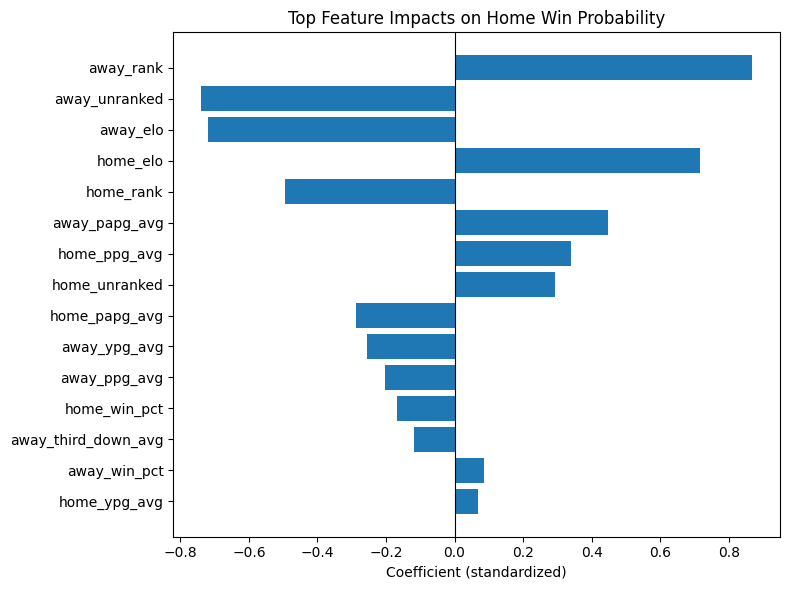

In [24]:
# @title
import numpy as np
import pandas as pd

# Pull coefficients out of the fitted model
coefs = model.coef_[0]
feature_names = X.columns  # same columns used to fit, in the same order

importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
}).sort_values('abs_coefficient', ascending=False)

importance.reset_index(drop=True, inplace=True)
print(importance)

importance['odds_ratio'] = np.exp(importance['coefficient'])

import matplotlib.pyplot as plt

top_n = 15
top_features = importance.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_features['feature'], top_features['coefficient'])
plt.xlabel('Coefficient (standardized)')
plt.title('Top Feature Impacts on Home Win Probability')
plt.gca().invert_yaxis()
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [25]:
# XGBOOST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

#
train_mask = df['season'] <= 2024
test_mask  = df['season'] >= 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model = XGBClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1: {f1_score(y_test, y_pred):.2f}")

y_proba = model.predict_proba(X_test)[:, 1]
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.2f}")

# Grab the identifying columns for the test set rows, same mask as before
results = df.loc[test_mask, ['season', 'date', 'home_team', 'away_team']].copy()

# Attach actual outcome, predicted outcome, and predicted probability
results['actual_home_win'] = y_test.values
results['predicted_home_win'] = y_pred
results['predicted_home_win_prob'] = model.predict_proba(X_test)[:, 1]

# Make it readable: translate 1/0 into an actual winner name
results['actual_winner'] = results.apply(
    lambda r: r['home_team'] if r['actual_home_win'] == 1 else r['away_team'], axis=1
)
results['predicted_winner'] = results.apply(
    lambda r: r['home_team'] if r['predicted_home_win'] == 1 else r['away_team'], axis=1
)

# Flag whether the model got it right
results['correct'] = results['actual_home_win'] == results['predicted_home_win']

Model Accuracy: 0.7664728682170543

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.60      0.63       337
           1       0.81      0.85      0.83       695

    accuracy                           0.77      1032
   macro avg       0.73      0.72      0.73      1032
weighted avg       0.76      0.77      0.76      1032

[[201 136]
 [105 590]]
Precision: 0.81
Recall: 0.85
F1: 0.83
ROC AUC: 0.82


In [26]:
results.to_csv('/content/test_predictions_2025_XGBOOST.csv', index=False)

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

train_mask = df['season'] <= 2024
test_mask  = df['season'] >= 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test.iloc[0:1]
prediction = rf_classifier.predict(sample)

sample_dict = sample.iloc[0].to_dict()

In [ ]:
results.to_csv('/content/test_predictions_2025_Random_Forest.csv', index=False)

In [ ]:
LR_games = pd.read_csv('/content/test_predictions_2025_Log_Reg.csv')
RF_games = pd.read_csv('/content/test_predictions_2025_Random_Forest.csv')
XG_games = pd.read_csv('/content/test_predictions_2025_XGBOOST.csv')

predicted_home_win_LR = LR_games['predicted_home_win']
predicted_home_win_RF = RF_games['predicted_home_win']
predicted_home_win_XG = XG_games['predicted_home_win']

predicted_home_win_prob_LR = LR_games['predicted_home_win_prob']
predicted_home_win_prob_RF = RF_games['predicted_home_win_prob']
predicted_home_win_prob_XG = XG_games['predicted_home_win_prob']

binary_ensemble_vote = []
prob_ensemble_vote = []
predicted_winner_binary = []
predicted_winner_prob = []
correct_binary = []
correct_prob = []
num_correct_binary = 0
num_correct_prob = 0

for i in range(len(predicted_home_win_LR)):
  binary_vote = (predicted_home_win_LR[i] + predicted_home_win_RF[i] + predicted_home_win_XG[i]) / 3
  prob_vote = (predicted_home_win_prob_LR[i] + predicted_home_win_prob_RF[i] + predicted_home_win_prob_XG[i]) / 3

  if binary_vote >= 0.5:
    binary_ensemble_vote.append(1)
    predicted_winner_binary.append(LR_games['home_team'][i])
  else:
    binary_ensemble_vote.append(0)
    predicted_winner_binary.append(LR_games['away_team'][i])

  if prob_vote >= 0.5:
    prob_ensemble_vote.append(1)
    predicted_winner_prob.append(LR_games['home_team'][i])
  else:
    prob_ensemble_vote.append(0)
    predicted_winner_prob.append(LR_games['away_team'][i])

  if predicted_winner_binary[i] == LR_games['actual_winner'][i]:
    correct_binary.append(True)
    num_correct_binary += 1
  else:
    correct_binary.append(False)

  if predicted_winner_prob[i] == LR_games['actual_winner'][i]:
    correct_prob.append(True)
    num_correct_prob += 1
  else:
    correct_prob.append(False)

data = {'season': LR_games['season'], 'date': LR_games['date'], 'home_team': LR_games['home_team'], 'away_team': LR_games['away_team'],
        'actual_home_win': LR_games['actual_home_win'], 'predicted_home_win_LR': predicted_home_win_LR, 'predicted_home_win_RF': predicted_home_win_RF,
        'predicted_home_win_XG': predicted_home_win_XG, 'binary_ensemble_vote': binary_ensemble_vote, 'prob_ensemble_vote': prob_ensemble_vote,
        'actual_winner': LR_games['actual_winner'], 'predicted_winner_binary': predicted_winner_binary, 'predicted_winner_prob': predicted_winner_prob,
        'correct_binary': correct_binary, 'correct_prob': correct_prob}

ensemble_results = pd.DataFrame(data)
ensemble_results.to_csv('/content/test_predictions_2025_Ensemble.csv', index=False)

accuracy = num_correct_binary / len(predicted_home_win_LR)
print(f"Accuracy of binary: {accuracy}")

accuracy = num_correct_prob / len(predicted_home_win_LR)
print(f"Accuracy of prob: {accuracy}")


In [ ]:
ensemble_results